# (24) new code: (64, 4.0)

**Motivation**: host = ```chewie```, device = ```cuda:0``` <br>

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-vae/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-vae/figs')
tmp_dir = os.path.join(git_dir, 'jb-vae/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_iclr_ipvae'))
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
from base.utils_model import load_model
from figures.analysis import plot_convergence
from figures.imgs import plot_weights

device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: chewie

## ICLR code: Poisson + vH16

In [3]:
model_type = 'poisson'
cfg_vae, cfg_tr = default_configs('vH16-wht', model_type, 'ngd|lin')

t_train = 64

cfg_vae['t_train'] = t_train
cfg_vae['kl_beta'] = 1/16 * t_train

cfg_vae['track_stats'] = True

### Make model + trainer

In [4]:
model = MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae))
tr = Trainer(model, ConfigTrain(**cfg_tr), device=device)

tr.n_iters

154500

### Print info

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  132.1 K   |
|     ———     |    ———     |
|    layer    |  132.1 K   |
+-------------+------------+

poisson_vH16-wht_t-64_b-4_k-512_<ngd|lin>
b200-ep300-lr(0.001)_temp(0.05:0.5)_gr(200)_(2025_05_24,21:39)

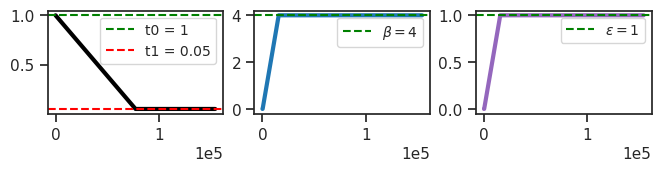

In [5]:
model.print()
tr.print()
tr.show_schedules()

In [6]:
model.layer.n_exp

tensor([151, 151, 151, 151, 151, 151, 151, 151, 151, 151, 151, 151, 151, 151,
        151, 151, 151, 151, 151, 151, 151, 151, 151, 151, 151, 151, 151, 151,
        151, 151, 151, 151, 151, 151, 151, 151, 151, 151, 151, 151, 151, 151,
        151, 151, 151, 151, 151, 151, 151, 151, 151, 151, 151, 151, 151, 151,
        151, 151, 151, 151, 151, 151, 151, 151], device='cuda:0',
       dtype=torch.int32)

In [7]:
model.cfg.track_stats

True

In [8]:
print(f"{vars(tr.model.cfg)}\n\n\n{vars(tr.cfg)}")

{'prior_log_dist': 'uniform', 'clamp_prior': -4, 'n_ch': 32, 't_train': 64, 'kl_beta': 4.0, 'n_latents': 512, 
'enc_type': 'ngd', 'dec_type': 'lin', 'dataset': 'vH16-wht', 'dataset_name': 'vH16-wht', 'feeder': 'stationary', 
'feeder_cfg': {}, 'input_sz': (1, 16, 16), 'shape': (-1, 1, 16, 16), 'clamp_vals': {'u': 8.0, 'du': 10.0, 'dec': 
3.45}, 'init_dist': 'normal', 'init_scale': 0.0001, 'recon_mode': 'mse', 'stochastic': True, 'fit_dec_var': False, 
'fit_prior': True, 'seed': 0, 'track_stats': True, 'base_dir': '/home/hadi/Projects/PoissonVAE', 'data_dir': 
'/home/hadi/Datasets', 'runs_dir': '/home/hadi/Projects/PoissonVAE/runs/poisson_vH16-wht_t-64_b-4_k-512_<ngd|lin>',
'mods_dir': '/home/hadi/Projects/PoissonVAE/models/poisson_vH16-wht_t-64_b-4_k-512_<ngd|lin>', 'results_dir': 
'/home/hadi/Projects/PoissonVAE/results'}


{'lr': 0.001, 'epochs': 300, 'batch_size': 200, 'dataset_kws': None, 'warm_restart': 0, 'warmup_portion': 0.005, 
'optimizer': 'adamax_fast', 'optimizer_kws': {'weight_decay': 0.0, 'betas': (0.9, 0.999), 'eps': 1e-08}, 
'scheduler_type': 'cosine', 'scheduler_kws': {'T_max': 298.5, 'eta_min': 1e-05}, 'ema_rate': None, 'grad_clip': 
200, 'chkpt_freq': 50, 'eval_freq': 20, 'log_freq': 10, 'method': 'mc', 'kl_beta_min': 0.0001, 'kl_balancer': None,
'kl_time_adjuster': None, 'kl_anneal_cycles': 0, 'kl_anneal_portion': 0.1, 'kl_const_portion': 0.001, 
'temp_anneal_portion': 0.5, 'temp_anneal_type': 'lin', 'temp_start': 1.0, 'temp_stop': 0.05}

In [9]:
print(tr.model.layer.dec)

None

### Fit model

In [10]:
tr.train('NewGold')

# tr.train()

Warning: Could not save code info: Reference at 'refs/heads/main' does not exist

epoch # 300, avg loss: 35.048: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 300/300 [11:46:43<00:00, 141.35s/it]


**Task:** reproduce this while gradually updating the code

**Conclusion:** 

In [12]:
print(model.layer.n_exp)

tensor([ 37,  54,  77, 103, 127, 143, 152, 156, 159, 159, 159, 159, 159, 159,
        158, 159, 159, 158, 158, 158, 158, 157, 158, 157, 157, 158, 158, 157,
        157, 157, 157, 157, 157, 157, 157, 157, 157, 157, 157, 157, 156, 156,
        157, 157, 156, 157, 156, 156, 157, 157, 157, 156, 157, 157, 157, 157,
        156, 156, 156, 156, 156, 157, 156, 157], device='cuda:0',
       dtype=torch.int32)

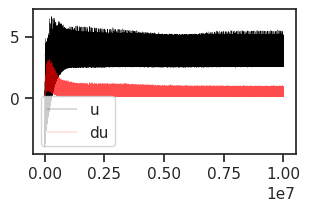

In [13]:
u_max = np.array(tr.model.stats['u_max'])
du_max = np.array(tr.model.stats['du_max'])

fig, ax = create_figure()
ax.plot(u_max, color='k', label='u', lw=0.2)
ax.plot(du_max, color='r', label='du', alpha=0.7, lw=0.2)
ax.legend()
plt.show()

100%|███████████████████████████████████| 2/2 [00:03<00:00,  1.51s/it]


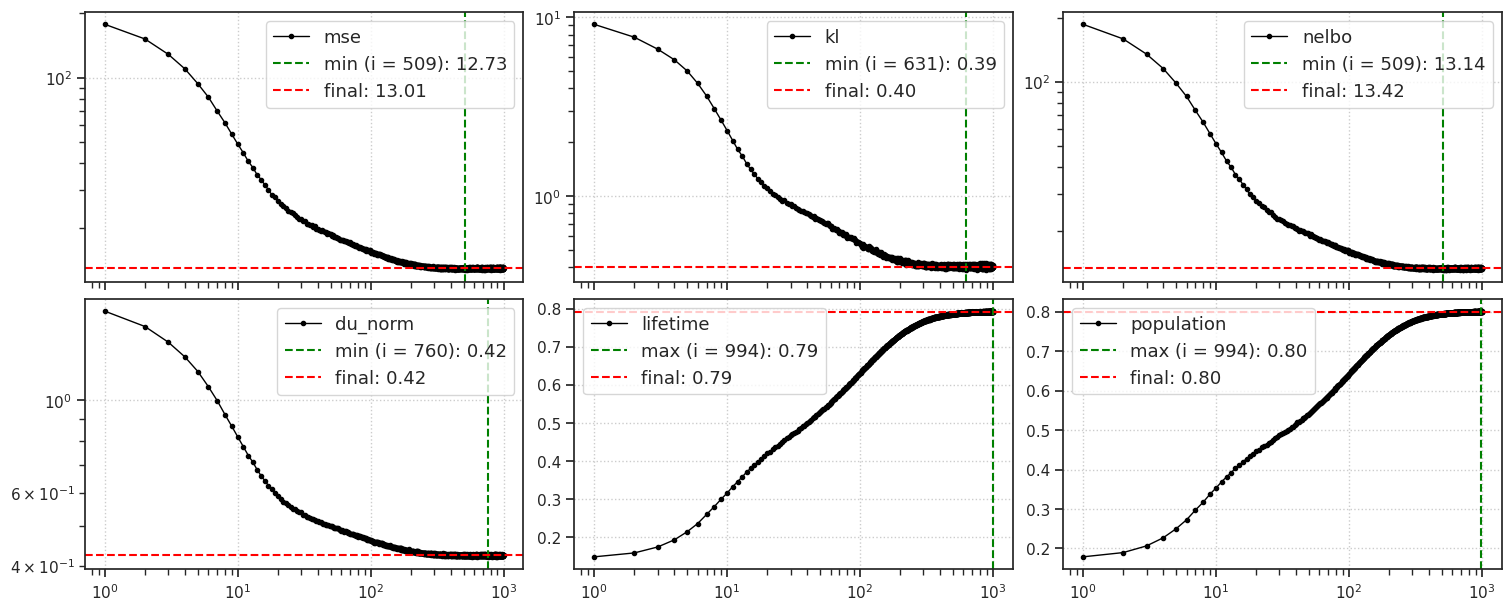

CPU times: user 5.95 s, sys: 18.8 ms, total: 5.97 s
Wall time: 5.96 s


In [14]:
%%time

kws = dict(
    seq_total=1000,
    n_data_batches=2,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')

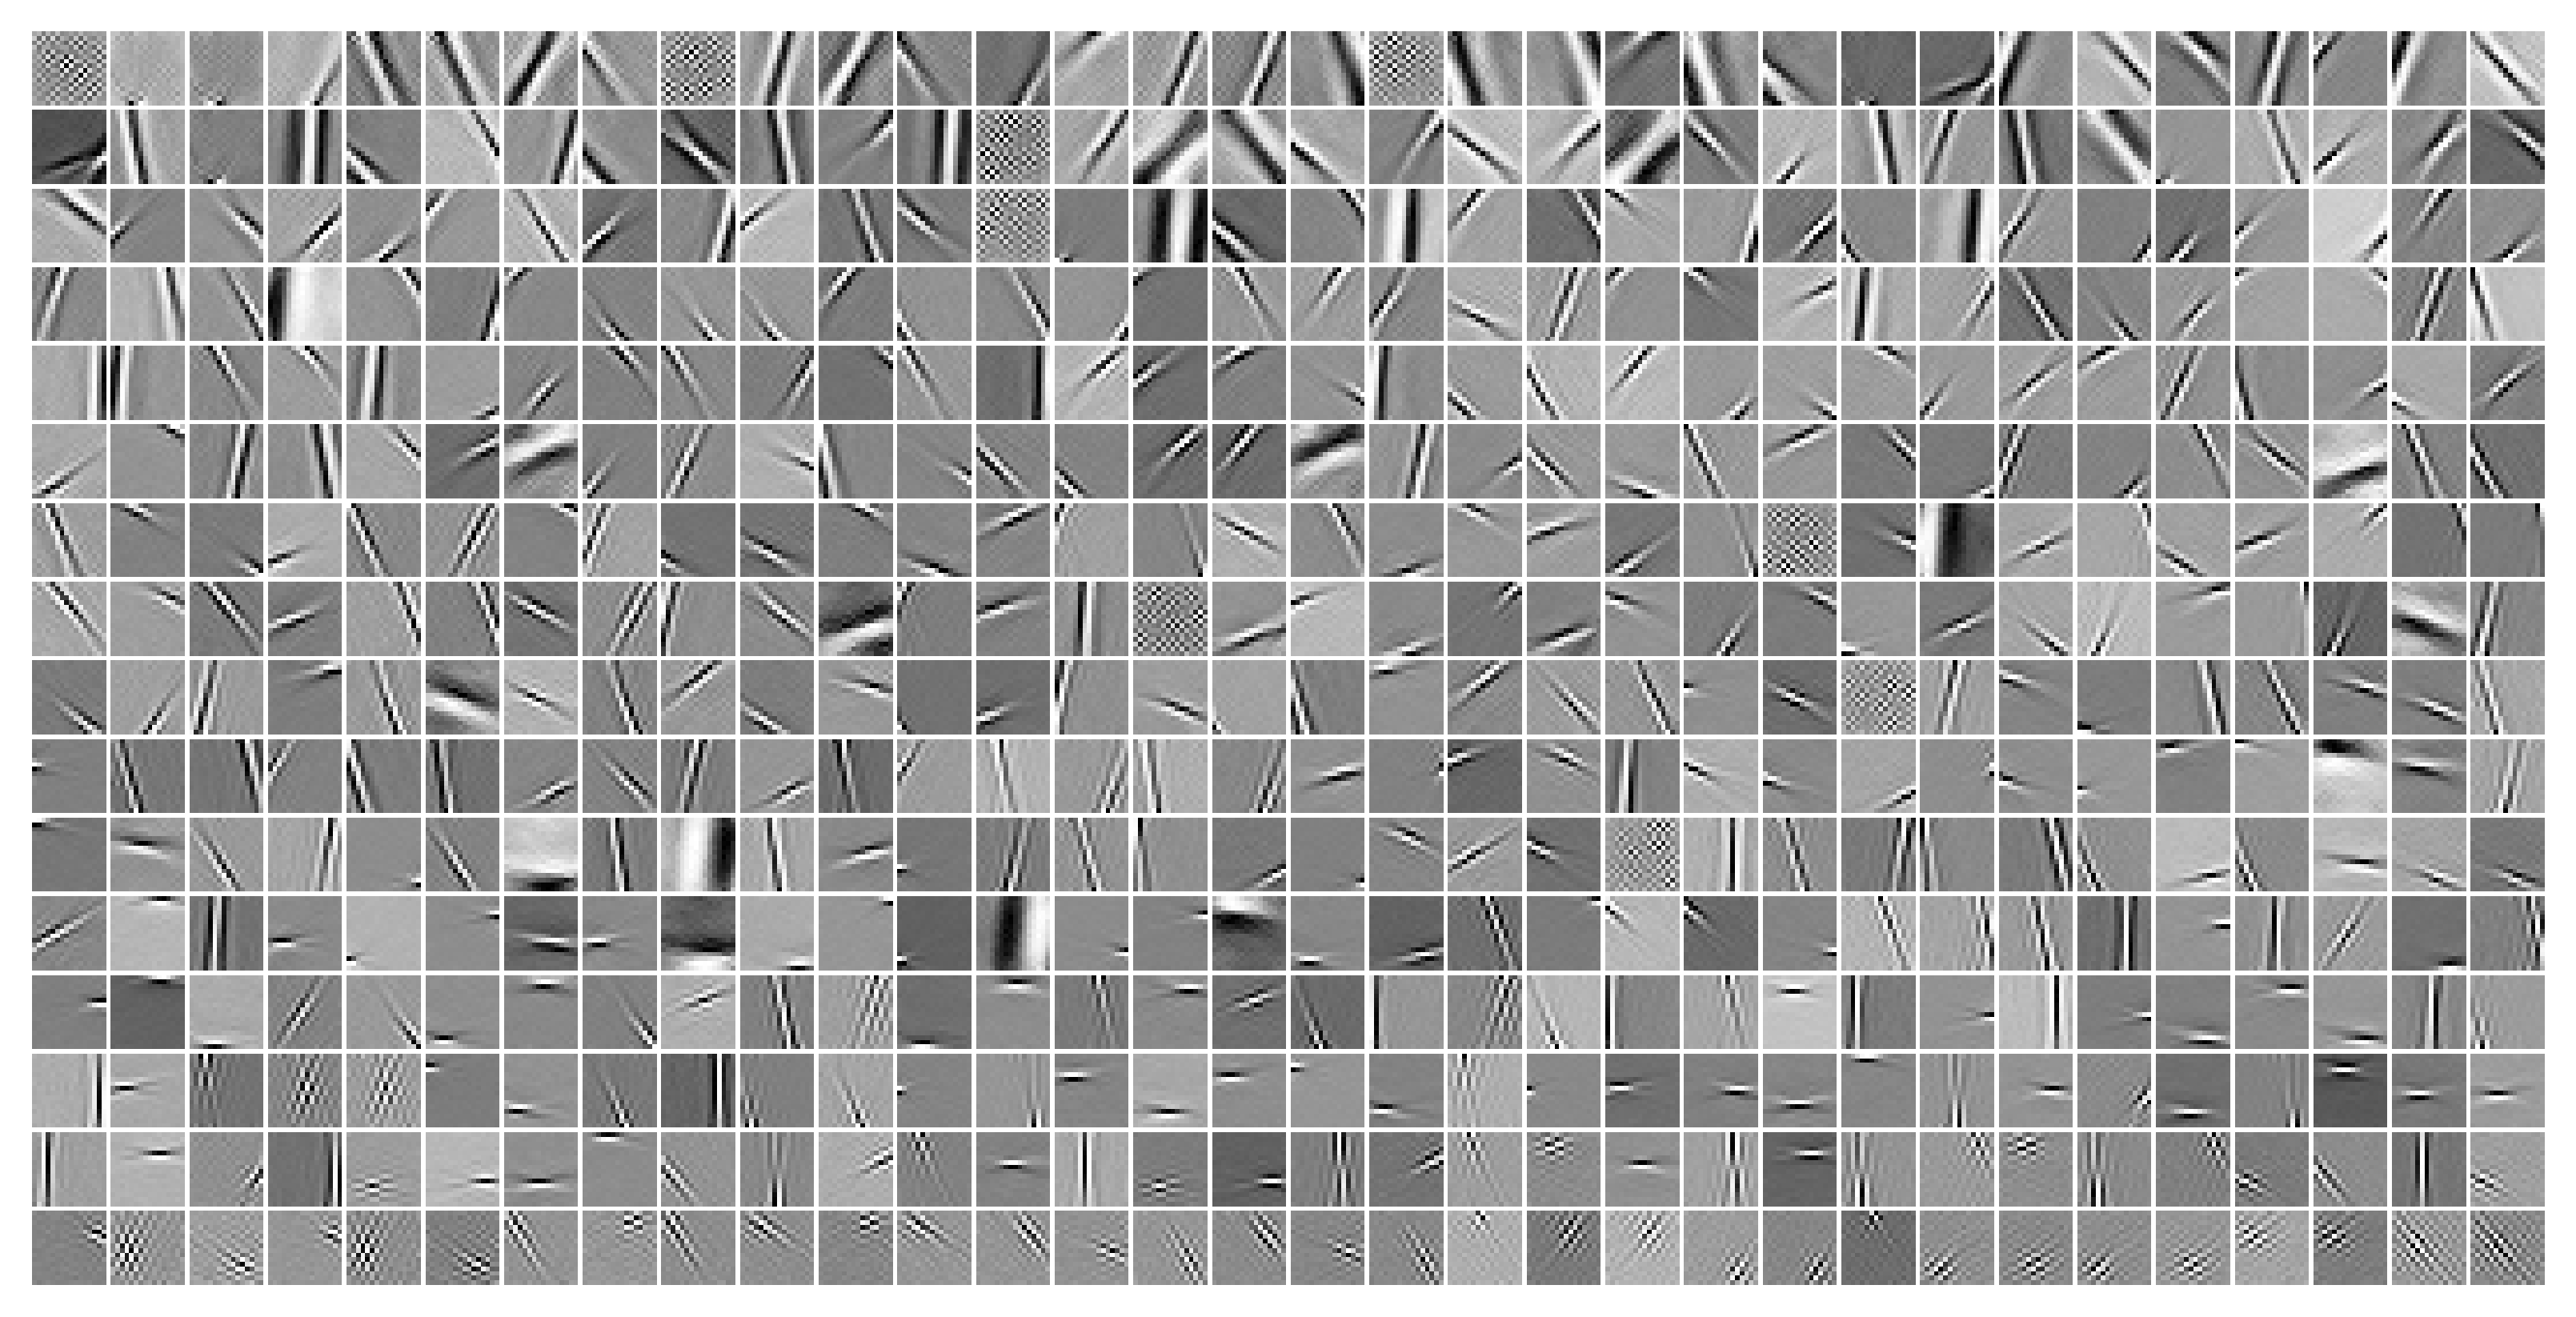

In [15]:
w = tr.model.layer.get_weight()
norms = tonp(torch.linalg.vector_norm(w, dim=1))
tr.model.show(order=np.argsort(norms), dpi=400, pad=1);

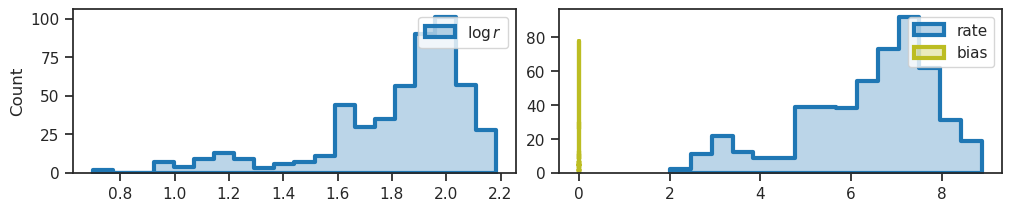

In [16]:
log_rate = tonp(tr.model.layer.u_init).ravel()
bias = tonp(tr.model.layer.log_bias.exp()).ravel()

fig, axes = create_figure(1, 2, (10, 2))
kws = dict(fill=True, lw=3, alpha=0.3, ax=axes[0])
sns.histplot(log_rate, color='C0', element='step', label=r'$\log r$', **kws)

kws = dict(fill=True, lw=3, alpha=0.3, ax=axes[1])
sns.histplot(np.exp(log_rate), color='C0', element='step', label='rate', **kws)
sns.histplot(bias, color='C8', element='step', label='bias', **kws)

axes[1].set(ylabel='')
add_legend(axes)

plt.show()

In [17]:
dead = log_rate < -1
dead.sum(), (~dead).sum(), dead.sum() / len(dead)

(0, 512, 0.0)

In [18]:
(bias > 0).mean()

1.0

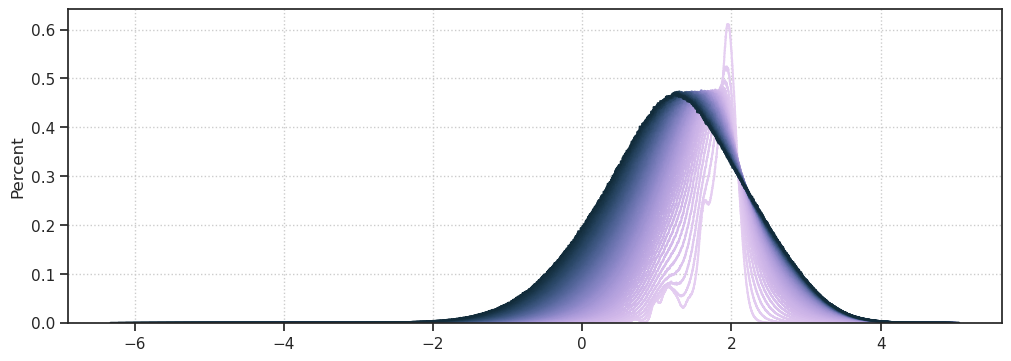

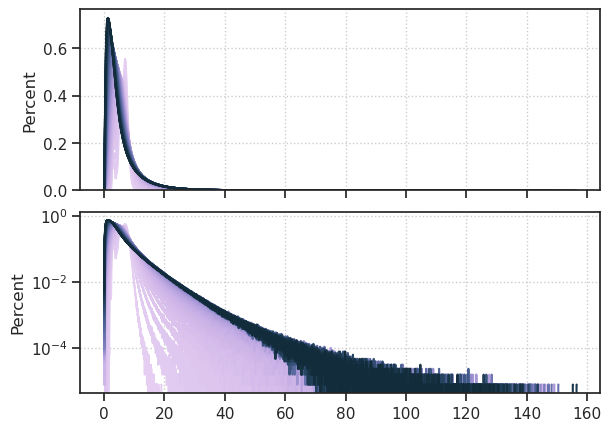

In [19]:
posterior_log_rates = collections.defaultdict(list)
for x, *_ in iter(tr.dl_vld):
    output = tr.model.xtract_ftr(x)
    for t, pois in output['posterior'].items():
        posterior_log_rates[t].append(torch.log(pois.rate))
posterior_log_rates = {
    t: tonp(torch.cat(v)) for t, v
    in posterior_log_rates.items()
}


fig, ax = create_figure(1, 1, (10, 3.5))
pal = get_cubehelix_palette(tr.model.cfg.t_train, start=2.5)

for i, (t, v) in enumerate(posterior_log_rates.items()):
    sns.histplot(
        v[:, ~dead].ravel(),
        stat='percent',
        element='step',
        fill=False,
        color=pal[i],
        label=f"T = {t}",
        ax=ax,
    )
# ax.legend()
ax.grid()
plt.show()


fig, axes = create_figure(2, 1, (6, 4.2), sharex='col')
for i, (t, v) in enumerate(posterior_log_rates.items()):
    for ax in axes.flat:
        sns.histplot(
            np.exp(v[:, ~dead].ravel()),
            stat='percent',
            element='step',
            fill=False,
            color=pal[i],
            label=f"T = {t}",
            ax=ax,
        )
axes[1].set(yscale='log')
add_grid(axes)
plt.show()

In [20]:
pal

[[0.8975507056831679, 0.8094812603307622, 0.9465577040964425],
 [0.8866123240173651, 0.7958983038519307, 0.9422918732191514],
 [0.8752970263731347, 0.7825260082915297, 0.9379240822047787],
 [0.8675492796390212, 0.7737271804565149, 0.9349467948701816],
 [0.8556294737467403, 0.7607012467427129, 0.9303698966493534],
 [0.8433620288876186, 0.7478796938980614, 0.9256448758128782],
 [0.8307588572555651, 0.7352595095847134, 0.920755401664727],
 [0.8178323483750889, 0.7228373334284097, 0.9156857084467959],
 [0.8045953480197278, 0.7106094643016453, 0.9104206137697519],
 [0.79560472689218, 0.7025635211553574, 0.906794768375293],
 [0.7818799577163285, 0.6906503712327243, 0.9011719061316577],
 [0.7678810179857369, 0.6789200520499765, 0.895316140152927],
 [0.7536222390910452, 0.6673676811663984, 0.8892145725288978],
 [0.7391183047885241, 0.6559880740597579, 0.8828549646148315],
 [0.7243842279061081, 0.6447757533596252, 0.8762257510361532],
 [0.7094353267375394, 0.6337249583933606, 0.8693160528666957],
 [0.6993577385770928, 0.6264445294016456, 0.8645487063100135],
 [0.6840855914209351, 0.6156494043651438, 0.8571492616027769],
 [0.6686407796183966, 0.6049991340541501, 0.8494437689559234],
 [0.6530395351595674, 0.5944870054682074, 0.8414239655082867],
 [0.6372982819344618, 0.5841060706815461, 0.833082325095353],
 [0.621433610824204, 0.5738491579616475, 0.8244120665462615],
 [0.6107968559632122, 0.5670764791822508, 0.8184463202131744],
 [0.5947637311136256, 0.5570097609434238, 0.8092153420349645],
 [0.5786520562132055, 0.5470469330879013, 0.7996413582804732],
 [0.5624788192426652, 0.537180102140577, 0.7897203759647626],
 [0.5462610574079536, 0.5274012056922577, 0.7794491739582197],
 [0.5300158317387482, 0.5177020247219766, 0.7688253061707515],
 [0.5137602016853071, 0.5080741960907603, 0.7578471038208457],
 [0.502925747750803, 0.501691094016707, 0.750330978090829],
 [0.4866906022573988, 0.49216324991999744, 0.7387606248388815],
 [0.47049034368637177, 0.4826838485599901, 0.7268352944905869],
 [0.4543418090218264, 0.47324410768280234, 0.7145561729846717],
 [0.4382617158505203, 0.46383516111091816, 0.7019252220281831],
 [0.4222666374319871, 0.4544480719647567, 0.68894517617112],
 [0.41165859076399486, 0.44819771588937396, 0.6800995692970601],
 [0.3958415626832449, 0.4388270462167934, 0.6665458619228831],
 [0.3801528514238289, 0.42945415804726944, 0.6526540980753568],
 [0.3646082907403786, 0.42006996959797827, 0.6384298063533692],
 [0.34922345634459306, 0.41066539098359633, 0.6238792625699561],
 [0.3340136422551673, 0.4012313377379247, 0.609009481727145],
 [0.31899383745488447, 0.39175874434318986, 0.5938282091118987],
 [0.3090934491249027, 0.3854178083786437, 0.5835384610223103],
 [0.29442273406185093, 0.3758609301156636, 0.5678571993546726],
 [0.27998033375032055, 0.36624153240241375, 0.5518885932348213],
 [0.26577992459661565, 0.3565507347057864, 0.5356429755155622],
 [0.2518347737894646, 0.34677973827838704, 0.5191313564287725],
 [0.23815771813777506, 0.33691983947377085, 0.5023654098822408],
 [0.22919475837445644, 0.33029293394003856, 0.49105287836119443],
 [0.2159918198929715, 0.32026582325789205, 0.4738907509899629],
 [0.20308894806968764, 0.31012716573160537, 0.45650855834617055],
 [0.1904972282574262, 0.2998687188513679, 0.4389202776631917],
 [0.17822722309223576, 0.2894823960320571, 0.4211404754406243],
 [0.1662889542130063, 0.27896027928163225, 0.40318428935094847],
 [0.158519102797742, 0.271866265196377, 0.39112323360373646],
 [0.1471544728114009, 0.2611007271666751, 0.3729082050883482],
 [0.13614552585465997, 0.2501791993868458, 0.35455980691569594],
 [0.12550015301583156, 0.23909448773253017, 0.3360951047782604],
 [0.11522562698887427, 0.22783962349552306, 0.3175316418450756],
 [0.10532858729656207, 0.2164078749887342, 0.2988874168171155],
 [0.09581502618943258, 0.2047927589221381, 0.28018086136798226],
 [0.08968835622664696, 0.19694439287329632, 0.267684484678481],
 [0.08082544199115693, 0.18500996673171594, 0.24891610683615542],
 [0.

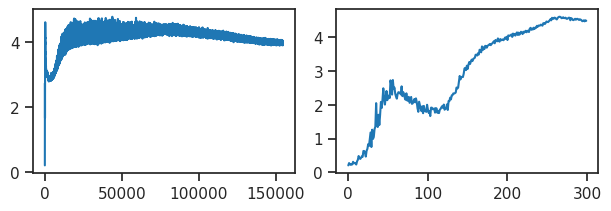

In [21]:
grad = np.array(list(tr.stats['grad'].values()))

fig, axes = create_figure(1, 2)
axes[0].plot(np.log(grad))
axes[1].plot(np.log(grad)[:300]);

In [22]:
(grad > 100).sum()

106

100%|███████████████████████████████| 130/130 [03:21<00:00,  1.55s/it]


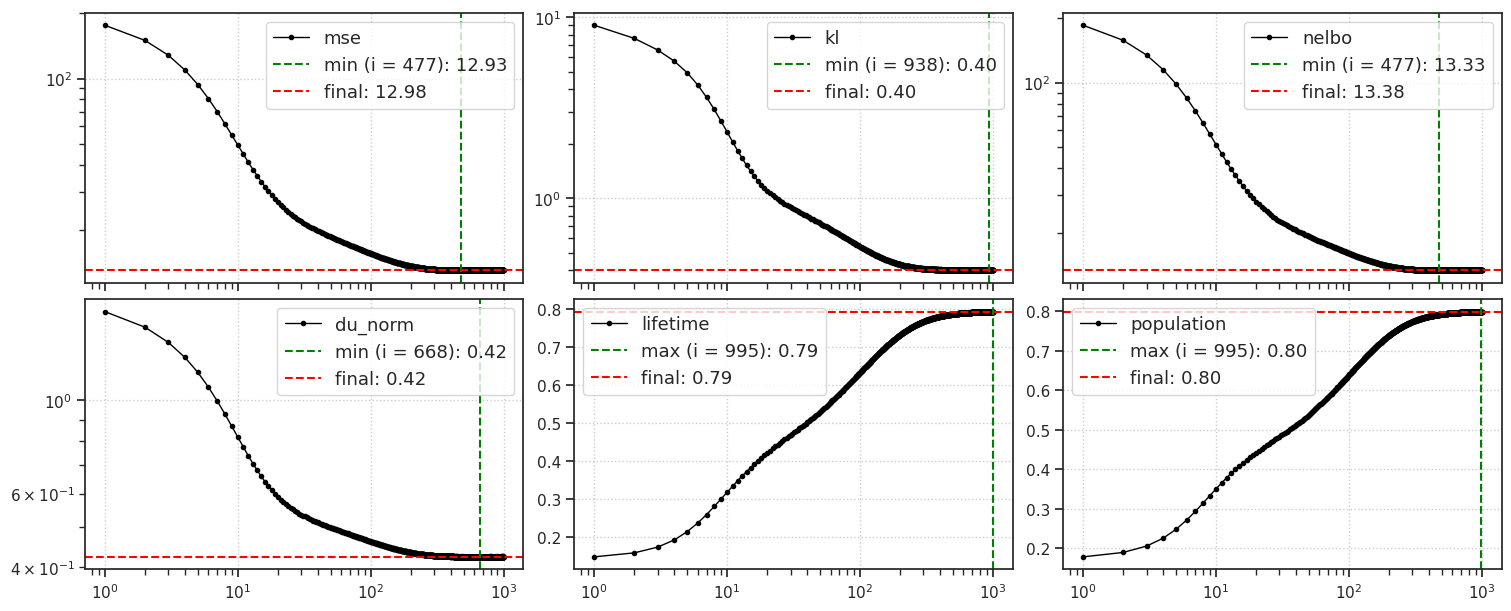

CPU times: user 4min 27s, sys: 6.03 s, total: 4min 33s
Wall time: 4min 34s


In [23]:
%%time

kws = dict(
    seq_total=1000,
    n_data_batches=None,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')